# 03 Keypose Marking

Instructor workflow to populate `master_data/chon_ji/keyposes_angles.json`.

**Goal**: Mark the completion frame of each of the 19 Chon-Ji movements so that
`segment_movements()` can achieve **"high" confidence** (both velocity valley AND
keypose signal agree within 5 frames).

## Workflow
1. **Auto-detect** 19 candidate frames from velocity valleys (run once)
2. **Watch** `chon_ji_master_overlay.mp4` and adjust `KEYPOSE_FRAMES` as needed
3. **Build** angle entries and save `keyposes_angles.json`
4. **Re-run** `segment_movements()` → verify high confidence ≥ 15/19


## Setup

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent))

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itf_analysis.segmentation.segmentor import load_poses_from_json
from itf_analysis.normalization.normalizer import normalize_pose, extract_joint_angles
from itf_analysis.segmentation.velocity_detector import (
    compute_motion_velocity, smooth_velocity, find_velocity_valleys,
)
from itf_analysis.segmentation.segmenter import segment_movements
from itf_analysis.segmentation.keypose_matcher import load_master_keyposes
from itf_analysis.segmentation.keypose_angle_marker import (
    build_angle_entry,
    save_keyposes_angles,
    load_keyposes_angles_or_empty,
    validate_keyposes_angles,
)

PROJECT_ROOT = pathlib.Path.cwd().parent.parent

# ── CONFIG ────────────────────────────────────────────────────────────────────
POOMSAE       = "chon_ji"   # 새 품새라면 이 값만 변경
NUM_MOVEMENTS = 19           # 품새 동작 수 (천지=19, 단군=21, 도산=24 등)
# ──────────────────────────────────────────────────────────────────────────────

poomsae_dir = PROJECT_ROOT / "itf_analysis" / "sample_videos" / POOMSAE
POSES_PATH  = str(poomsae_dir / "master_poses.json")
OUTPUT_PATH = str(PROJECT_ROOT / "itf_analysis" / "master_data" / POOMSAE / "keyposes_angles.json")

print(f"Poses  : {POSES_PATH}")
print(f"Output : {OUTPUT_PATH}")

## Step 0 — Load poses and extract angles

In [40]:
frames = load_poses_from_json(POSES_PATH)
fps = 1000.0 / (frames[1].timestamp_ms - frames[0].timestamp_ms)

all_frame_angles = []
for fr in frames:
    norm = normalize_pose(fr.landmarks)
    if norm is None:
        continue
    all_frame_angles.append((fr.frame_index, extract_joint_angles(norm)))

# Build frame → angles lookup for later
angles_by_frame = {fi: fa for fi, fa in all_frame_angles}

print(f"Frames loaded : {len(frames)}")
print(f"FPS           : {fps:.1f}")
print(f"Angle frames  : {len(all_frame_angles)}")

Frames loaded : 1153
FPS           : 30.0
Angle frames  : 1151


## Step 1 — Auto-detect velocity candidate frames

Run velocity pipeline to get 19 candidate frames.  
These are used as starting points — adjust them in `KEYPOSE_FRAMES` below.

In [ ]:
frame_indices = [fi for fi, _ in all_frame_angles]

# ── SET THIS before running ───────────────────────────────────────────────────
END_FRAME = 1081   # 품새 마지막 프레임 — 자기자리 복귀는 이 프레임 이후
# ─────────────────────────────────────────────────────────────────────────────

velocity = compute_motion_velocity(all_frame_angles, fps)
smoothed = smooth_velocity(velocity, fps, sigma_seconds=0.1)
valleys  = find_velocity_valleys(smoothed, fps, min_gap_sec=0.5)

total_range = frame_indices[-1] - frame_indices[0]
avg_mov     = total_range / NUM_MOVEMENTS
half_window = max(1, int(avg_mov * 0.45))

print(f"Full range : {frame_indices[0]}–{frame_indices[-1]}")
print(f"END_FRAME  : {END_FRAME}")
print(f"avg_mov    : {avg_mov:.1f} frames   half_window : {half_window}")

candidate_frames = {}
prev      = frame_indices[0] - 1
last_det  = frame_indices[0]

for i in range(NUM_MOVEMENTS):
    mov = i + 1
    exp = round(last_det + avg_mov)

    lo = max(frame_indices[0], prev + 1, exp - half_window)
    hi = min(END_FRAME, exp + half_window)
    if hi >= END_FRAME:
        lo = max(frame_indices[0], prev + 1)
    if lo > hi:
        lo = hi = exp

    in_window = [v for v in valleys if lo <= frame_indices[v] <= hi]
    if in_window:
        best_v = min(in_window, key=lambda v: smoothed[v])
        candidate_frames[mov] = frame_indices[best_v]
    else:
        candidate_frames[mov] = exp

    last_det = candidate_frames[mov]
    prev     = candidate_frames[mov]

print(f"\nVelocity candidate frames:")
for mov, fr in candidate_frames.items():
    print(f"  Movement {mov:2d}: frame {fr}")

## Step 2 — Set `KEYPOSE_FRAMES`

**Instructions:**
1. Watch `sample_videos/chon_ji_master_overlay.mp4` (or `chon_ji_master.mp4`)
2. For each movement, find the exact frame where the technique is fully completed  
   (body fully stopped, final posture held)
3. Update the frame numbers below — the candidate values are pre-filled from velocity detection

| # | Movement |
|---|----------|
| 1 | Left walking stance, left high block |
| 2 | Right walking stance, right middle punch |
| 3 | Right walking stance, right high block |
| 4 | Left walking stance, left middle punch |
| 5 | Left L-stance, right inner forearm block |
| 6 | Right walking stance, right middle punch |
| 7 | Right L-stance, left inner forearm block |
| 8 | Left walking stance, left middle punch |
| 9 | Left walking stance, left low block |
| 10 | Right walking stance, right middle punch |
| 11 | Right walking stance, right low block |
| 12 | Left walking stance, left middle punch |
| 13 | Left walking stance, left middle punch (2nd) |
| 14 | Right walking stance, right middle punch |
| 15 | Left L-stance, right knife-hand block |
| 16 | Right walking stance, right middle punch |
| 17 | Right L-stance, left knife-hand block |
| 18 | Left walking stance, left middle punch |
| 19 | Left walking stance, left middle punch (final) |

In [ ]:
# ── EDIT THESE FRAME NUMBERS ──────────────────────────────────────────────────
KEYPOSE_FRAMES = {mov: fr for mov, fr in candidate_frames.items()}

# Manual overrides — uncomment and edit as needed:
# KEYPOSE_FRAMES[1]  = 87
# ─────────────────────────────────────────────────────────────────────────────

# ── MOVEMENT METADATA ─────────────────────────────────────────────────────────
# Format: {movement_number: ("internal_snake_case_name", "ITF technique name")}
# For a NEW poomsae: clear this dict and fill in your own entries.
# Movements not listed here get auto-generated generic names.
MOVEMENT_META = {
    1:  ("left_walking_high_block",           "Ap Kubi Olgul Makgi (L)"),
    2:  ("right_walking_middle_punch",         "Ap Kubi Kaunde Jirugi (R)"),
    3:  ("right_walking_high_block",           "Ap Kubi Olgul Makgi (R)"),
    4:  ("left_walking_middle_punch",          "Ap Kubi Kaunde Jirugi (L)"),
    5:  ("left_l_stance_inner_forearm_block",  "Niunja Sogi An Palmok Makgi (L)"),
    6:  ("right_walking_middle_punch_2",       "Ap Kubi Kaunde Jirugi (R)"),
    7:  ("right_l_stance_inner_forearm_block", "Niunja Sogi An Palmok Makgi (R)"),
    8:  ("left_walking_middle_punch_2",        "Ap Kubi Kaunde Jirugi (L)"),
    9:  ("left_walking_low_block",             "Ap Kubi Najunde Makgi (L)"),
    10: ("right_walking_middle_punch_3",       "Ap Kubi Kaunde Jirugi (R)"),
    11: ("right_walking_low_block",            "Ap Kubi Najunde Makgi (R)"),
    12: ("left_walking_middle_punch_3",        "Ap Kubi Kaunde Jirugi (L)"),
    13: ("left_walking_middle_punch_4",        "Ap Kubi Kaunde Jirugi (L) x2"),
    14: ("right_walking_middle_punch_4",       "Ap Kubi Kaunde Jirugi (R)"),
    15: ("left_l_stance_knifehand_block",      "Niunja Sogi Sonkal Makgi (L)"),
    16: ("right_walking_middle_punch_5",       "Ap Kubi Kaunde Jirugi (R)"),
    17: ("right_l_stance_knifehand_block",     "Niunja Sogi Sonkal Makgi (R)"),
    18: ("left_walking_middle_punch_5",        "Ap Kubi Kaunde Jirugi (L)"),
    19: ("left_walking_middle_punch_final",    "Ap Kubi Kaunde Jirugi (L) — final"),
}
# ─────────────────────────────────────────────────────────────────────────────

def _get_meta(mov: int):
    if mov in MOVEMENT_META:
        return MOVEMENT_META[mov]
    return (f"movement_{mov}", f"Movement {mov}")

print("KEYPOSE_FRAMES:")
for mov, fr in KEYPOSE_FRAMES.items():
    name, itf = _get_meta(mov)
    print(f"  {mov:2d}  frame {fr:5d}  {name}")

## Step 2b — Visualise candidate frames on velocity curve

Check that each marked frame sits near a velocity valley.  
Frames far from a valley may need manual correction.

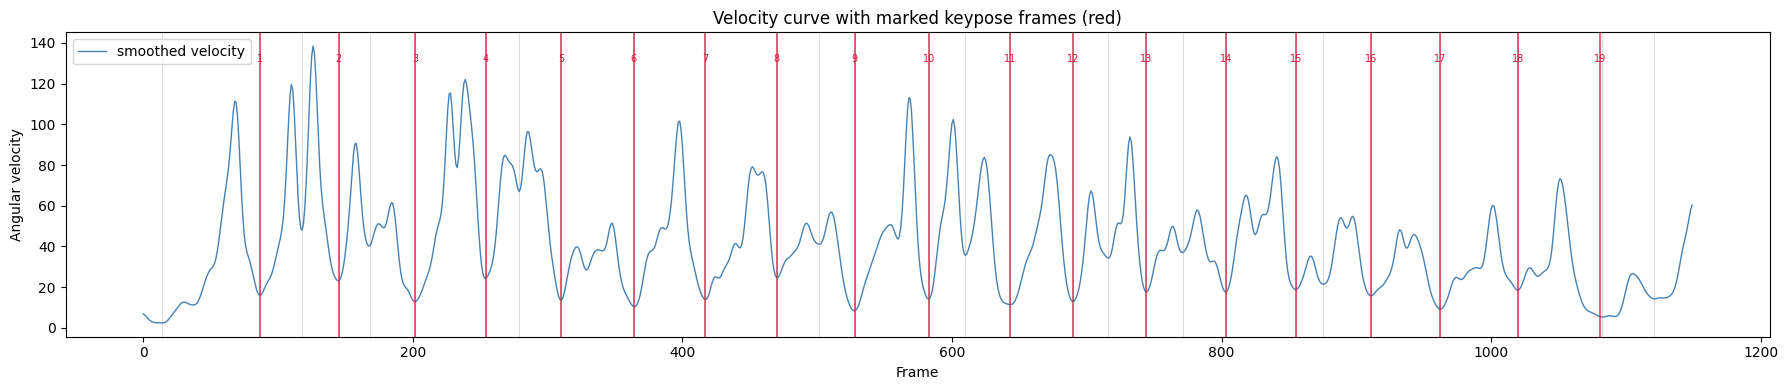

In [43]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(frame_indices[:-1], smoothed, color="steelblue", lw=1, label="smoothed velocity")

for v in valleys:
    ax.axvline(frame_indices[v], color="lightgray", lw=0.6, zorder=0)

for mov, fr in KEYPOSE_FRAMES.items():
    ax.axvline(fr, color="crimson", lw=1.2, alpha=0.8)
    y_pos = smoothed[max(0, frame_indices.index(fr) - 1)] if fr in frame_indices else 0
    ax.text(fr, ax.get_ylim()[1] * 0.9, str(mov), ha="center", fontsize=7, color="crimson")

ax.set_xlabel("Frame")
ax.set_ylabel("Angular velocity")
ax.set_title("Velocity curve with marked keypose frames (red)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Build angle entries and save

In [ ]:
keyposes = []
missing  = []

for mov in range(1, NUM_MOVEMENTS + 1):
    fr = KEYPOSE_FRAMES[mov]
    name, itf = _get_meta(mov)
    entry = build_angle_entry(
        angles_by_frame=angles_by_frame,
        frame_index=fr,
        movement_index=mov,
        movement_name=name,
        itf_name=itf,
    )
    if entry is None:
        print(f"  [WARNING] Movement {mov}: frame {fr} not in angles_by_frame")
        missing.append(mov)
    else:
        keyposes.append(entry)

print(f"\nBuilt {len(keyposes)} entries, {len(missing)} missing")
if keyposes:
    sample = keyposes[0]
    print(f"\nSample entry (movement 1):")
    print(f"  movement_name : {sample['movement_name']}")
    print(f"  source_frame  : {sample['source_frame']}")
    print(f"  angle keys    : {list(sample['angles'].keys())}")

## Step 4 — Validate

In [ ]:
data = {"poomsae": POOMSAE, "keyposes": keyposes}
errors = validate_keyposes_angles(data, expected_count=NUM_MOVEMENTS)

if errors:
    print(f"{len(errors)} validation error(s):")
    for e in errors:
        print(f"  - {e}")
else:
    print(f"All {NUM_MOVEMENTS} keyposes valid — ready to save")

## Step 5 — Save `keyposes_angles.json`

Run this cell only after validation passes (0 errors).

In [ ]:
import os

if not errors:
    os.makedirs(str(PROJECT_ROOT / "itf_analysis" / "master_data" / POOMSAE), exist_ok=True)
    save_keyposes_angles(keyposes, OUTPUT_PATH, poomsae=POOMSAE)
else:
    print("Fix errors above before saving.")

## Step 6 — Re-run segmentation and check confidence

After saving `keyposes_angles.json`, re-run `segment_movements()`.  
Expected: **≥ 15/19 "high" confidence** on master-on-master self-test.

In [ ]:
from collections import Counter
import warnings

master_keyposes = load_master_keyposes(OUTPUT_PATH)
print(f"Keyposes loaded: {len(master_keyposes)} / {NUM_MOVEMENTS}")
print(f"END_FRAME used : {END_FRAME}  (frames beyond this are ignored)")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    boundaries = segment_movements(all_frame_angles, master_keyposes, fps, end_frame=END_FRAME)

conf_count = Counter(b.confidence for b in boundaries)
print(f"\nConfidence: high={conf_count['high']}  medium={conf_count['medium']}  low={conf_count['low']}")

print(f"\n{'Mov':>4} {'frame':>6} {'conf':>8}  signals")
print("-" * 50)
for b in boundaries:
    flag = " ✓" if b.confidence == "high" else " ·" if b.confidence == "medium" else " ✗"
    print(f"{b.movement_number:>4} {b.frame:>6} {b.confidence:>8}  {b.matched_signals}{flag}")

if caught:
    print(f"\n{len(caught)} warning(s):")
    for w in caught:
        print(f"  {w.message}")

gate_target = int(NUM_MOVEMENTS * 0.79)  # 79% high 기준 (천지 기준 15/19)
gate = conf_count["high"] >= gate_target
print(f"\nMaster-on-master gate: {'PASS ✓' if gate else 'FAIL ✗'}  ({conf_count['high']}/{NUM_MOVEMENTS} high  |  target >= {gate_target})")

## Step 7 — Confidence summary plot

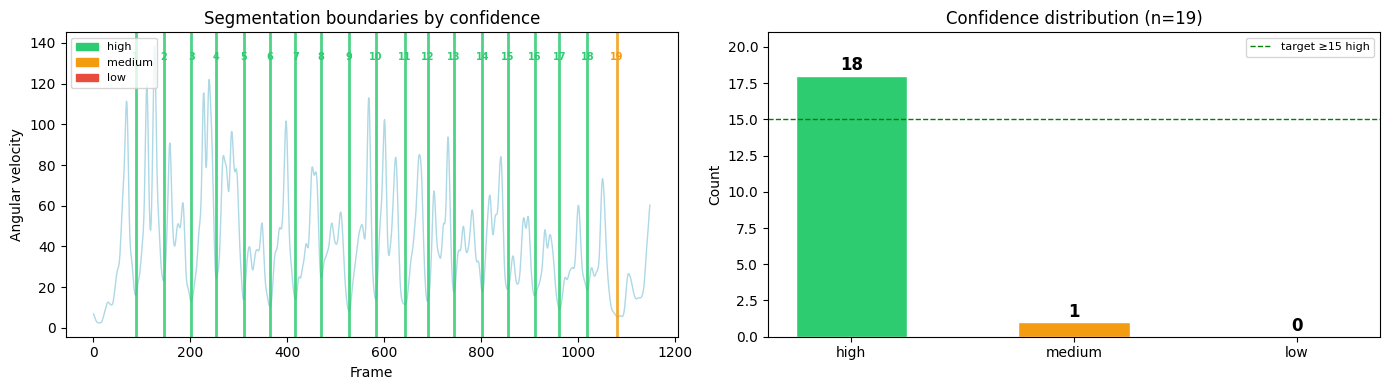


Master-on-master gate: PASS ✓  (18/19 high)


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: velocity curve coloured by confidence ──────────────────────────────
ax = axes[0]
ax.plot(frame_indices[:-1], smoothed, color="lightblue", lw=1)

CONF_COLOR = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
for b in boundaries:
    c = CONF_COLOR[b.confidence]
    ax.axvline(b.frame, color=c, lw=2, alpha=0.85)
    ax.text(b.frame, smoothed.max() * 0.95, str(b.movement_number),
            ha="center", fontsize=7, color=c, fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in CONF_COLOR.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_xlabel("Frame")
ax.set_ylabel("Angular velocity")
ax.set_title("Segmentation boundaries by confidence")

# ── Right: confidence bar chart ───────────────────────────────────────────────
ax2 = axes[1]
labels = ["high", "medium", "low"]
counts = [conf_count[l] for l in labels]
colors = [CONF_COLOR[l] for l in labels]
bars = ax2.bar(labels, counts, color=colors, edgecolor="white", width=0.5)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             str(cnt), ha="center", va="bottom", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 21)
ax2.set_ylabel("Count")
ax2.set_title(f"Confidence distribution (n=19)")
ax2.axhline(15, color="green", lw=1, ls="--", label="target ≥15 high")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

gate = conf_count["high"] >= 15
print(f"\nMaster-on-master gate: {'PASS ✓' if gate else 'FAIL ✗'}  ({conf_count['high']}/19 high)")